# Análise de Acessibilidade do Portal IFBA

Este *notebook* consome diretamente os arquivos de resultado em `results/`
(gerados pela suíte de coleta com axe-core e IBM Equal Access Checker) e
reproduz integralmente a análise do Capítulo 5: panorama geral, violações por
ferramenta, itens de revisão manual, distribuição por critério WCAG e princípio
POUR, perfil de impacto e a comparação entre os motores.

Toda a lógica de agregação vive no pacote testado `a11y`; aqui apenas carregamos
os dados, montamos as tabelas e figuras e as exibimos. Reexecutar este *notebook*
após uma nova coleta atualiza todos os números e figuras automaticamente.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

cwd = Path.cwd()
if (cwd / 'analysis').exists():
    sys.path.insert(0, str(cwd / 'analysis'))
    base = cwd
else:
    base = cwd.parent

from a11y import aggregate, convergence
from a11y.load import load_results

RESULTS_DIR = base / 'results'
FIGURES_DIR = base / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

results = load_results(RESULTS_DIR)

PRINCIPLE_PT = {
    'Perceivable': 'Perceptível',
    'Operable': 'Operável',
    'Understandable': 'Compreensível',
    'Robust': 'Robusto',
}
DEVICE_PT = {'desktop': 'Desktop (1280×720)', 'mobile': 'Mobile (375×667)'}
BUCKET_PT = {
    'violation': 'Violações confirmadas',
    'potentialviolation': 'Violações potenciais',
    'recommendation': 'Recomendações',
    'potentialrecommendation': 'Recomendações potenciais',
    'manual': 'Verificação manual',
    'pass': 'Itens aprovados',
}

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['figure.dpi'] = 110


def show(df):
    from IPython.display import display
    display(df)
    print(df.to_markdown(index=False))

## Contexto de execução

Metadados embutidos em cada arquivo de resultado, tornando a execução
autocontida e auditável.

In [2]:
context = pd.DataFrame([
    {
        'Dispositivo': DEVICE_PT[r.metadata.device],
        'Ferramenta': r.metadata.tool,
        'Versão da ferramenta': r.metadata.tool_version,
        'Navegador': f'{r.metadata.browser} {r.metadata.browser_version}',
        'URL': r.metadata.url,
        'Timestamp': r.metadata.timestamp,
    }
    for r in results
])
show(context)

,Dispositivo,Ferramenta,Versão da ferramenta,Navegador,URL,Timestamp
0,Desktop (1280×720),axe-core,4.12.1,chromium 149.0.7827.55,https://portal.ifba.edu.br/dgcom/defeso-eleito...,2026-07-12T21:40:15.333Z
1,Desktop (1280×720),ibm-equal-access,4.0.26,chromium 149.0.7827.55,https://portal.ifba.edu.br/dgcom/defeso-eleito...,2026-07-12T21:40:27.908Z
2,Mobile (375×667),axe-core,4.12.1,chromium 149.0.7827.55,https://portal.ifba.edu.br/dgcom/defeso-eleito...,2026-07-12T21:40:09.708Z
3,Mobile (375×667),ibm-equal-access,4.0.26,chromium 149.0.7827.55,https://portal.ifba.edu.br/dgcom/defeso-eleito...,2026-07-12T21:40:17.815Z


| Dispositivo        | Ferramenta       | Versão da ferramenta   | Navegador              | URL                                                    | Timestamp                |
|:-------------------|:-----------------|:-----------------------|:-----------------------|:-------------------------------------------------------|:-------------------------|
| Desktop (1280×720) | axe-core         | 4.12.1                 | chromium 149.0.7827.55 | https://portal.ifba.edu.br/dgcom/defeso-eleitoral/2026 | 2026-07-12T21:40:15.333Z |
| Desktop (1280×720) | ibm-equal-access | 4.0.26                 | chromium 149.0.7827.55 | https://portal.ifba.edu.br/dgcom/defeso-eleitoral/2026 | 2026-07-12T21:40:27.908Z |
| Mobile (375×667)   | axe-core         | 4.12.1                 | chromium 149.0.7827.55 | https://portal.ifba.edu.br/dgcom/defeso-eleitoral/2026 | 2026-07-12T21:40:09.708Z |
| Mobile (375×667)   | ibm-equal-access | 4.0.26                 | chromium 149.0.7827.55 | https://portal.ifba.edu.br/d

## Panorama geral das violações

Para o axe-core reportam-se regras distintas violadas e ocorrências em nível de
elemento; para o IBM, as violações confirmadas (itens de nível *violation*). As
taxonomias diferem, portanto os números não devem ser equiparados diretamente.

In [3]:
overview = pd.DataFrame(aggregate.overview(results)).rename(columns={
    'device': 'Viewport',
    'axe_rules': 'axe-core (regras)',
    'axe_occurrences': 'axe-core (ocorrências)',
    'ibm_violations': 'IBM (violações)',
})
overview['Viewport'] = overview['Viewport'].map(DEVICE_PT)
show(overview)

,Viewport,axe-core (regras),axe-core (ocorrências),IBM (violações)
0,Desktop (1280×720),2,28,14
1,Mobile (375×667),1,8,12


| Viewport           |   axe-core (regras) |   axe-core (ocorrências) |   IBM (violações) |
|:-------------------|--------------------:|-------------------------:|------------------:|
| Desktop (1280×720) |                   2 |                       28 |                14 |
| Mobile (375×667)   |                   1 |                        8 |                12 |


## Violações identificadas pelo axe-core

Regra, critério WCAG associado, nível de conformidade, impacto atribuído pela
ferramenta e ocorrências por *viewport*.

In [4]:
axe = pd.DataFrame(aggregate.axe_rules(results))
axe['wcag'] = axe['wcag'].str.join(' / ')
axe = axe.rename(columns={
    'rule_id': 'Regra', 'wcag': 'Critério WCAG', 'level': 'Nível',
    'impact': 'Impacto', 'desktop': 'Desktop', 'mobile': 'Mobile',
})
show(axe)

,Regra,Critério WCAG,Nível,Impacto,Desktop,Mobile
0,target-size,2.5.8,AA,serious,21,0
1,link-name,2.4.4 / 4.1.2,A,serious,7,8


| Regra       | Critério WCAG   | Nível   | Impacto   |   Desktop |   Mobile |
|:------------|:----------------|:--------|:----------|----------:|---------:|
| target-size | 2.5.8           | AA      | serious   |        21 |        0 |
| link-name   | 2.4.4 / 4.1.2   | A       | serious   |         7 |        8 |


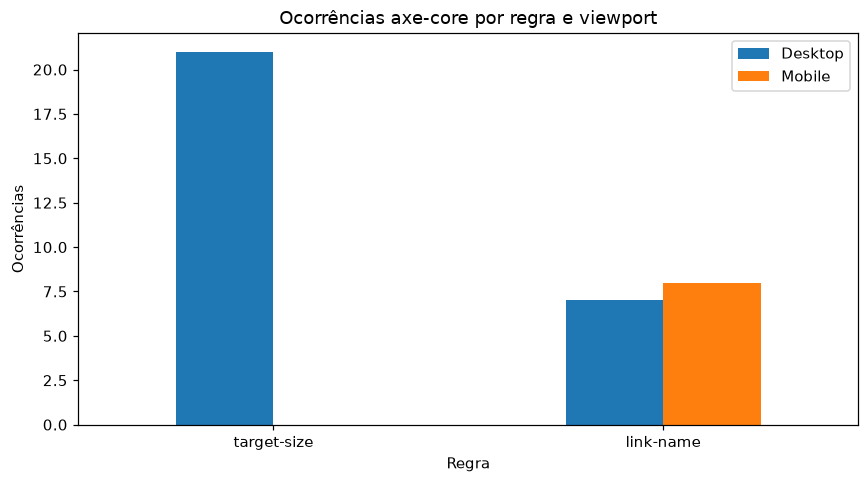

In [5]:
axe_fig = pd.DataFrame(aggregate.axe_rules(results)).set_index('rule_id')[['desktop', 'mobile']]
ax = axe_fig.plot.bar(rot=0)
ax.set_xlabel('Regra')
ax.set_ylabel('Ocorrências')
ax.set_title('Ocorrências axe-core por regra e viewport')
ax.legend(['Desktop', 'Mobile'])
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'axe-rules.pdf')
plt.show()

## Violações identificadas pelo IBM Equal Access Checker

O IBM organiza os achados por identificadores de regra próprios; o critério WCAG
é atribuído a partir do mapeamento mantido no pacote de análise.

In [6]:
ibm = pd.DataFrame(aggregate.ibm_rules(results))
ibm['wcag'] = ibm['wcag'].str.join(' / ')
ibm = ibm.rename(columns={
    'rule_id': 'ruleId', 'wcag': 'Critério WCAG', 'level': 'Nível',
    'desktop': 'Desktop', 'mobile': 'Mobile',
})
show(ibm)

,ruleId,Critério WCAG,Nível,Desktop,Mobile
0,a_text_purpose,2.4.4 / 4.1.2,A,7,8
1,aria_content_in_landmark,1.3.1,A,6,3
2,img_alt_redundant,1.1.1,A,1,1


| ruleId                   | Critério WCAG   | Nível   |   Desktop |   Mobile |
|:-------------------------|:----------------|:--------|----------:|---------:|
| a_text_purpose           | 2.4.4 / 4.1.2   | A       |         7 |        8 |
| aria_content_in_landmark | 1.3.1           | A       |         6 |        3 |
| img_alt_redundant        | 1.1.1           | A       |         1 |        1 |


## Itens por categoria (IBM) — contexto de revisão manual

Além das violações confirmadas, o IBM reporta um volume expressivo de itens que
demandam julgamento humano, extraídos do objeto `summary.counts`. Reforçam que a
avaliação automatizada cobre apenas uma fração dos critérios WCAG.

In [7]:
buckets = pd.DataFrame(aggregate.ibm_buckets(results))
buckets['category'] = buckets['category'].map(BUCKET_PT)
buckets = buckets.rename(columns={'category': 'Categoria', 'desktop': 'Desktop', 'mobile': 'Mobile'})
show(buckets)

,Categoria,Desktop,Mobile
0,Violações confirmadas,14,12
1,Violações potenciais,38,29
2,Recomendações,1,1
3,Recomendações potenciais,69,35
4,Verificação manual,16,7
5,Itens aprovados,4983,2427


| Categoria                |   Desktop |   Mobile |
|:-------------------------|----------:|---------:|
| Violações confirmadas    |        14 |       12 |
| Violações potenciais     |        38 |       29 |
| Recomendações            |         1 |        1 |
| Recomendações potenciais |        69 |       35 |
| Verificação manual       |        16 |        7 |
| Itens aprovados          |      4983 |     2427 |


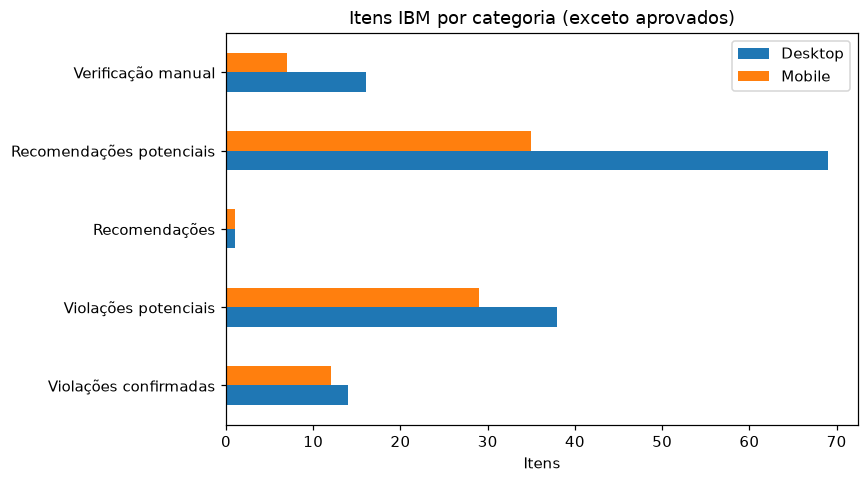

In [8]:
review = pd.DataFrame(aggregate.ibm_buckets(results))
review = review[review['category'] != 'pass'].copy()
review['category'] = review['category'].map(BUCKET_PT)
ax = review.set_index('category')[['desktop', 'mobile']].plot.barh()
ax.set_xlabel('Itens')
ax.set_ylabel('')
ax.set_title('Itens IBM por categoria (exceto aprovados)')
ax.legend(['Desktop', 'Mobile'])
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ibm-buckets.pdf')
plt.show()

## Distribuição por critério WCAG e princípio POUR

Ocorrências agregadas por critério WCAG e o princípio POUR correspondente, para
cada motor.

In [9]:
def criterion_table(tool):
    df = pd.DataFrame(aggregate.by_criterion(results, tool))
    df['principle'] = df['principle'].map(PRINCIPLE_PT)
    return df.rename(columns={
        'criterion': 'Critério WCAG', 'principle': 'Princípio',
        'level': 'Nível', 'occurrences': 'Ocorrências',
    })

print('axe-core')
show(criterion_table('axe-core'))
print('\nIBM Equal Access')
show(criterion_table('ibm-equal-access'))

axe-core


,Critério WCAG,Princípio,Nível,Ocorrências
0,2.4.4,Operável,A,15
1,2.5.8,Operável,AA,21
2,4.1.2,Robusto,A,15


| Critério WCAG   | Princípio   | Nível   |   Ocorrências |
|:----------------|:------------|:--------|--------------:|
| 2.4.4           | Operável    | A       |            15 |
| 2.5.8           | Operável    | AA      |            21 |
| 4.1.2           | Robusto     | A       |            15 |

IBM Equal Access


,Critério WCAG,Princípio,Nível,Ocorrências
0,1.1.1,Perceptível,A,2
1,1.3.1,Perceptível,A,9
2,2.4.4,Operável,A,15
3,4.1.2,Robusto,A,15


| Critério WCAG   | Princípio   | Nível   |   Ocorrências |
|:----------------|:------------|:--------|--------------:|
| 1.1.1           | Perceptível | A       |             2 |
| 1.3.1           | Perceptível | A       |             9 |
| 2.4.4           | Operável    | A       |            15 |
| 4.1.2           | Robusto     | A       |            15 |


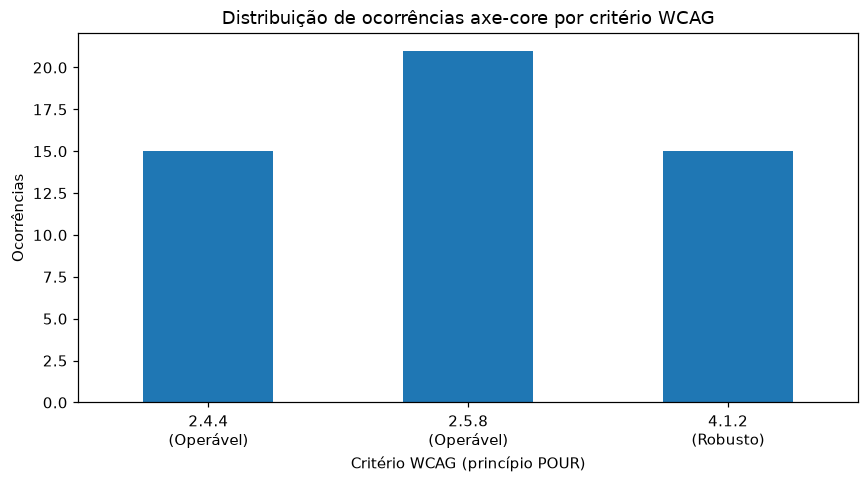

In [10]:
crit = pd.DataFrame(aggregate.by_criterion(results, 'axe-core'))
crit['label'] = crit['criterion'] + '\n(' + crit['principle'].map(PRINCIPLE_PT) + ')'
ax = crit.plot.bar(x='label', y='occurrences', rot=0, legend=False)
ax.set_xlabel('Critério WCAG (princípio POUR)')
ax.set_ylabel('Ocorrências')
ax.set_title('Distribuição de ocorrências axe-core por critério WCAG')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'wcag-criteria.pdf')
plt.show()

## Perfil de impacto (axe-core)

Distribuição das ocorrências do axe-core pelo nível de impacto atribuído pela
ferramenta. O IBM não classifica achados por severidade, portanto o perfil de
impacto é baseado no axe-core.

In [11]:
impact = pd.DataFrame(aggregate.by_impact(results)).rename(
    columns={'impact': 'Impacto', 'occurrences': 'Ocorrências'})
show(impact)

,Impacto,Ocorrências
0,serious,36


| Impacto   |   Ocorrências |
|:----------|--------------:|
| serious   |            36 |


## Convergências e divergências entre os motores

Como axe-core e IBM usam taxonomias de regras distintas, a comparação é feita
por critério WCAG: critérios sinalizados por ambos os motores (convergência) e
critérios exclusivos de cada motor (pontos cegos específicos de cada ferramenta).

In [12]:
partition = convergence.compare(results)
comparison = pd.DataFrame([
    {'Grupo': 'Ambos os motores', 'Critérios WCAG': ' / '.join(partition['shared'])},
    {'Grupo': 'Somente axe-core', 'Critérios WCAG': ' / '.join(partition['axe_only'])},
    {'Grupo': 'Somente IBM', 'Critérios WCAG': ' / '.join(partition['ibm_only'])},
])
show(comparison)

,Grupo,Critérios WCAG
0,Ambos os motores,2.4.4 / 4.1.2
1,Somente axe-core,2.5.8
2,Somente IBM,1.1.1 / 1.3.1


| Grupo            | Critérios WCAG   |
|:-----------------|:-----------------|
| Ambos os motores | 2.4.4 / 4.1.2    |
| Somente axe-core | 2.5.8            |
| Somente IBM      | 1.1.1 / 1.3.1    |
